In [2]:

# Inverse Transform Smapling (Lorentzian)

import matplotlib.pyplot as plt
import numpy as np



In [3]:

def lorentzian_histogram(n, bins=100, xmin=-10, xmax=10):
    """
    Sample n random points from the Lorentzian distribution
    using inverse transform sampling. Make a histogram with
    the specified bin count and range. Returns counts.
    """
    u = np.random.random(n) # Uniform(0,1)
    x = 1. / np.tan(np.pi * u) # x = 1/tan(pi*u)
    counts, _ = np.histogram(x, bins=bins, range=(xmin, xmax))
    return counts # No need to return bin edges for uniform bins


def lorentzPDF(x, gamma=1):

    p = (gamma / np.pi) / ((gamma ** 2) + (x ** 2))

    return p

def lorentzCDF(x, gamma=1):

    F = (1 / np.pi) * np.arctan(x / gamma) + (1 / 2)

    return F


In [4]:
bins = 100

counts = lorentzian_histogram(bins)
print(counts)


[ 0  0  0  0  0  0  0  0  0  1  0  1  0  0  0  0  0  0  0  1  0  0  0  0
  0  0  0  0  1  2  1  2  2  0  1  0  1  1  1  3  3  3  0  2  2  1  2  8
  4  4 10  3  6  2  6  4  2  3  2  1  3  0  0  0  0  0  0  1  0  2  0  0
  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0  1  0  2  0  0  0  0  0  0
  0  0  0  0]


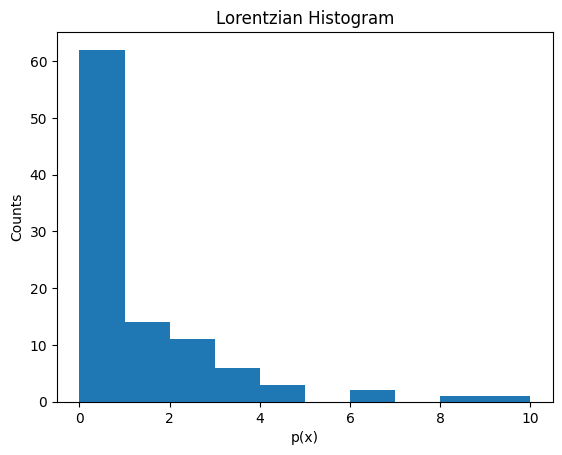

In [5]:
plt.hist(counts, bins='auto')

plt.title("Lorentzian Histogram")
plt.xlabel("p(x)")
plt.ylabel("Counts")

plt.show()

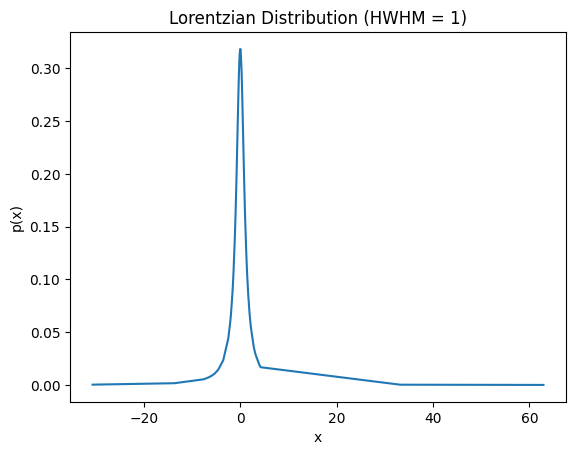

In [6]:
# x = gamma / tan(pi * u)
gamma = 1

#uArr = np.linspace(0.001,1, bins)

uArr = np.sort(np.random.rand(bins))
x = gamma / np.tan(np.pi * uArr)
#print(x)

p = lorentzPDF(x, gamma=gamma)

pNorm = (p - np.min(p)) / (np.max(p) - np.min(p))

plt.plot(x, p)

plt.title("Lorentzian Distribution (HWHM = 1)")
plt.xlabel("x")
plt.ylabel("p(x)")

plt.show()


[0.         0.11111111 0.22222222 0.33333333 0.44444444 0.55555556
 0.66666667 0.77777778 0.88888889 1.        ]
[0.0589342  0.17118333 0.28354192]


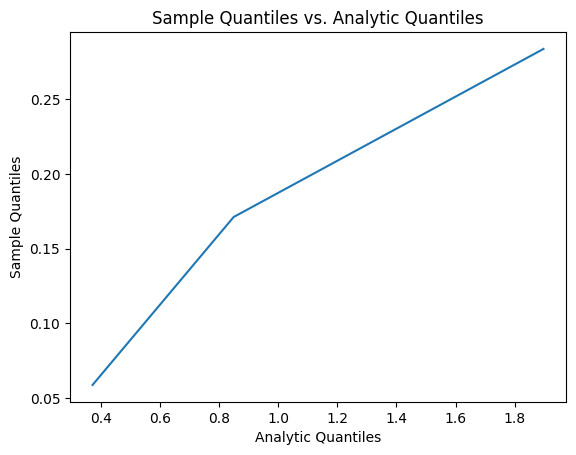

In [21]:
qArr = np.linspace(0,1,10)
print(qArr)
qArr = np.array([0.25, 0.5, 0.75])
sampleQs = np.quantile(p, qArr)
analyticQs = np.quantile(x[x>=0],qArr)

print(sampleQs)

plt.plot(analyticQs, sampleQs)

plt.title("Sample Quantiles vs. Analytic Quantiles")
plt.xlabel("Analytic Quantiles")
plt.ylabel("Sample Quantiles")

plt.show()

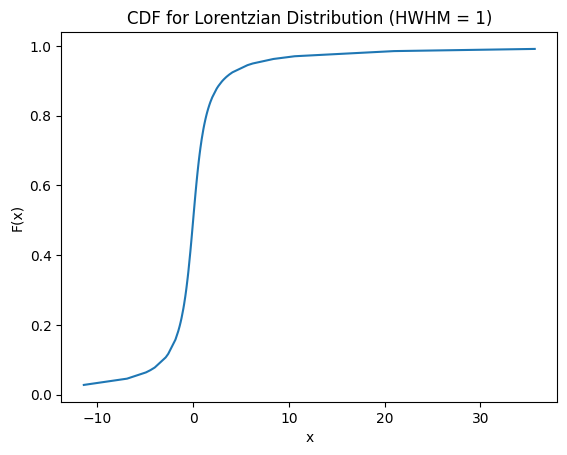

In [ ]:

F = lorentzCDF(x, gamma=gamma)

plt.plot(x, F)

plt.title("CDF for Lorentzian Distribution (HWHM = 1)")
plt.xlabel("x")
plt.ylabel("F(x)")

plt.show()